# Strategy Comparison Notebook

This notebook runs and compares:
1. **Baseline Strategies**: Long Only, Short Only, TSMOM
2. **LSTM Model**: Deep Momentum Network
3. **LSTM-GCN Model**: Graph-enhanced Deep Momentum Network

After each strategy, metrics are displayed including:
- E[Ret.], Vol., Sharpe, Sortino, Max Drawdown, Calmar, Hit Rate, Avg P/L Ratio
- Volatility-normalized returns (15% target)

## 1. Setup

In [43]:
import os
import sys

# Clone repo (Colab) or use local path
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

In [44]:
# Install dependencies if needed
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

from empyrical import (
    sharpe_ratio,
    sortino_ratio,
    max_drawdown,
    annual_return,
    annual_volatility,
    calmar_ratio,
    downside_risk
)

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [46]:
# Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
TEST_WINDOW_SIZE = 6  # years
NUM_REPEATS = 1

VOL_TARGET = 0.15  # 15% volatility target for normalization

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")

Train: 2011-2017
Test:  2017-2023


In [47]:
df = pd.read_csv("data/straddle_features/features.csv")
df['date'] = pd.to_datetime(df['date'])
df_2017 = df[df['date'].dt.year == 2017]

print(f"Days in 2017: {df_2017['date'].nunique()}")
print(f"\ntarget_returns stats:")
print(df_2017['target_returns'].describe())
print(f"\nExtreme values (|x| > 1): {(df_2017['target_returns'].abs() > 1).sum()}")

Days in 2017: 239

target_returns stats:
count    21032.000000
mean        -0.000670
std          0.009833
min         -0.063575
25%         -0.005330
50%         -0.001466
75%          0.002632
max          0.065704
Name: target_returns, dtype: float64

Extreme values (|x| > 1): 0


## 2. Helper Functions

In [48]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    
    # Format percentages
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    
    # Format ratios
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe for multiple strategies."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Rolling 252-day Sharpe
    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Yearly Sharpe Comparison
    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/strategy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_loss_curve(results_dir, title="Training Loss"):
    """Plot training loss curve if available."""
    loss_plot_path = os.path.join(results_dir, 'loss_plot.png')
    if os.path.exists(loss_plot_path):
        img = plt.imread(loss_plot_path)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
        plt.show()
    else:
        print(f"Loss plot not found at: {loss_plot_path}")

In [49]:
# Store all results for final comparison
all_metrics = []
all_daily_returns = {}

---
## 3. LSTM-GCN Model (Graph Strategy)

Run the LSTM-GCN model first as it will be used as the reference for classical strategies.

In [50]:
# Cell: Configure which graph LSTM-GCN uses

filepath = 'gml/graph_model_2.py'

# ============================================
# CHOOSE YOUR GRAPH TYPE:
# ============================================
GRAPH_TYPE = "pearson"  # Options: "cvx" or "pearson"

# For CVX graph - set alpha and beta:
ALPHA = 100
BETA = 0.01

# For Pearson graph - set threshold:
TAU = 0.40
# ============================================

with open(filepath, 'r') as f:
    content = f.read()

# Remove any existing graph_file line and replace with chosen option
import re

# Find and replace the graph_file assignment (handles both commented and uncommented versions)
pattern = r'(\s+)(#?\s*graph_file = os\.path\.join\("data", "graph_structure", "cvx_opt".*\n\s*#?\s*graph_file = os\.path\.join\("data", "graph_structure", "pearson".*)'

if GRAPH_TYPE == "cvx":
    replacement = f'''\\1graph_file = os.path.join("data", "graph_structure", "cvx_opt", f"{ALPHA}_{BETA}_cvx.csv")
\\1# graph_file = os.path.join("data", "graph_structure", "pearson", f"{TAU}.csv")'''
elif GRAPH_TYPE == "pearson":
    replacement = f'''\\1# graph_file = os.path.join("data", "graph_structure", "cvx_opt", f"{{alpha}}_{{beta}}_cvx.csv")
\\1graph_file = os.path.join("data", "graph_structure", "pearson", "{TAU}.csv")'''

content = re.sub(pattern, replacement, content)

with open(filepath, 'w') as f:
    f.write(content)

print(f"✓ Configured to use {GRAPH_TYPE.upper()} graph")
if GRAPH_TYPE == "cvx":
    print(f"  → data/graph_structure/cvx_opt/{ALPHA}_{BETA}_cvx.csv")
else:
    print(f"  → data/graph_structure/pearson/{TAU}.csv")

✓ Configured to use PEARSON graph
  → data/graph_structure/pearson/0.4.csv


In [51]:
from examples.run_graph_strategy import main as run_graph_main

print("="*60)
print("Running LSTM-GCN Model")
print("="*60)

run_graph_main(
    "LSTM-GCN",
    TRAIN_START,
    TEST_START,
    TEST_END,
    TEST_WINDOW_SIZE,
    NUM_REPEATS
)

Trial 1 Complete [00h 04m 52s]
val_loss: -1.2033113241195679

Best val_loss So Far: -1.2033113241195679
Total elapsed time: 00h 04m 52s
completed HP search
best_hp: {'hidden_layer_size': 10, 'dropout_rate': 0.4, 'max_gradient_norm': 0.01, 'learning_rate': 0.001, 'gcn_units': 16, 'gcn_layers': 2, 'alpha': 100, 'beta': 0.01, 'batch_size': 32}
Stacked LSTM output shape: (None, 20, 88, 10)
After GCN, shape: (None, 20, 88, 16)
Residual shape: (None, 20, 88, 16)
After adding residual, shape: (None, 20, 88, 16)
Final model input shape: (None, 88, 20, 10)
Final model output shape: (None, 88, 20, 1)
best_model: <Functional name=functional_1, built=True>
Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 235s 50s/step - loss: 0.6810 - val_loss: 0.6325
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step - loss: 0.6270 - val_loss: 0.6196
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step - loss: 0.5979 - val_loss: 0.6117
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step - loss: 0.6020 - val_loss: 0.6001
Epoch 5


LSTM-GCN Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN,5.64%,5.67%,0.995,1.420,5.91%,0.954,55.07%,0.980



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN (Vol-Norm),14.80%,15.00%,0.995,1.420,15.04%,0.984,55.07%,0.980



Yearly Sharpe Ratios:
  2017: 3.5518
  2018: 1.3051
  2019: 1.7641
  2020: 0.2069
  2021: 0.3104
  2022: -0.0394




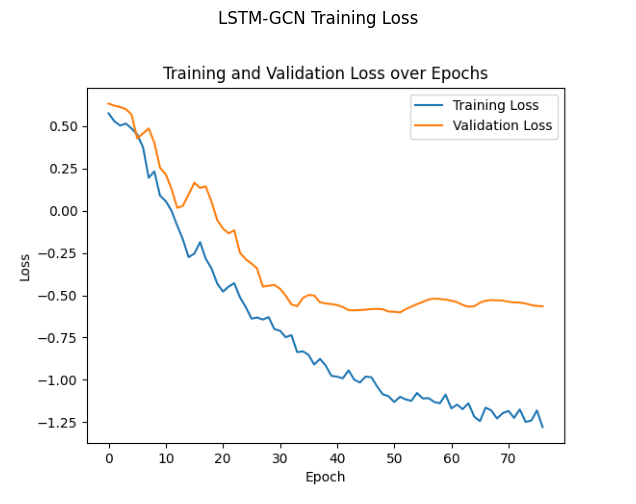

In [52]:
# Load LSTM-GCN results
LSTM_GCN_EXPERIMENT = "exp_lstm_gcn_split80_lstm-gcn_cpnone_len20_notime_val_v1"
lstm_gcn_results_dir = f"results/{LSTM_GCN_EXPERIMENT}/{TEST_START}-{TEST_END}"

lstm_gcn_csv = os.path.join(lstm_gcn_results_dir, "captured_returns_sw.csv")
if os.path.exists(lstm_gcn_csv):
    lstm_gcn_df = load_captured_returns(lstm_gcn_csv)
    lstm_gcn_returns = calc_daily_returns(lstm_gcn_df)
    
    # Raw metrics
    print("\n" + "="*60)
    print("LSTM-GCN Results (Raw)")
    print("="*60)
    metrics_raw = calc_metrics(lstm_gcn_returns, "LSTM-GCN")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['LSTM-GCN'] = lstm_gcn_returns
    
    # Vol-normalized metrics
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, scaled_returns = calc_metrics_vol_normalized(lstm_gcn_returns, "LSTM-GCN", VOL_TARGET)
    display_metrics(metrics_norm)
    
    # Yearly Sharpes
    print("\nYearly Sharpe Ratios:")
    yearly_sharpes = calc_yearly_sharpes(lstm_gcn_returns)
    for year, sharpe in yearly_sharpes.items():
        print(f"  {year}: {sharpe:.4f}")
    
    # Loss curve
    print("\n")
    plot_loss_curve(lstm_gcn_results_dir, "LSTM-GCN Training Loss")
else:
    print(f"Results not found at: {lstm_gcn_csv}")

---
## 4. LSTM Model (DNN Strategy)

In [7]:
from examples.run_dnn_strategy import main as run_dnn_main

print("="*60)
print("Running LSTM Model")
print("="*60)

run_dnn_main(
    "LSTM",
    TRAIN_START,
    TEST_START,
    TEST_END,
    TEST_WINDOW_SIZE,
    NUM_REPEATS
)

Trial 1 Complete [00h 00m 55s]
val_loss: -0.8675896525382996

Best val_loss So Far: -0.8675896525382996
Total elapsed time: 00h 00m 55s


self.time_steps: 20
self.input_size: 10


LSTM Input shape: (None, 20, 10)
LSTM output shape: (None, 20, 5)




Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 5)          │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 1)          │             6 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326 (1.27 KB)

 Trainable params: 326 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: -0.6677 - val_loss: -0.7104
Epoch 2/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -0.9680 - val_loss: -0.7032
Epoch 3/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.0027 - val_loss: -0.7291
Epoch 4/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.0756 - val_loss: -0.7099
Epoch 5/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -1.0642 - val_loss: -0.7365
Epoch 6/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -1.0941 - val_loss: -0.7760
Epoch 7/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.0789 - val_loss: -0.7412
Epoch 8/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.0769 - val_loss: -0.7706
Epoch 9/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.1377 - val_loss: -0.7755
Epoch 10/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.0968 - val_loss: -0.7912
Epoch 11/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.1539 - val_loss: -0.7829
Epoch 12/300
121/1


LSTM Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM,2.29%,2.07%,1.103,1.596,3.14%,0.727,59.07%,0.889



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM (Vol-Norm),16.67%,15.00%,1.103,1.596,21.54%,0.774,59.07%,0.889



Yearly Sharpe Ratios:
  2017: 4.2749
  2018: 0.1031
  2019: 2.9804
  2020: 0.6493
  2021: 1.7613
  2022: 0.7927




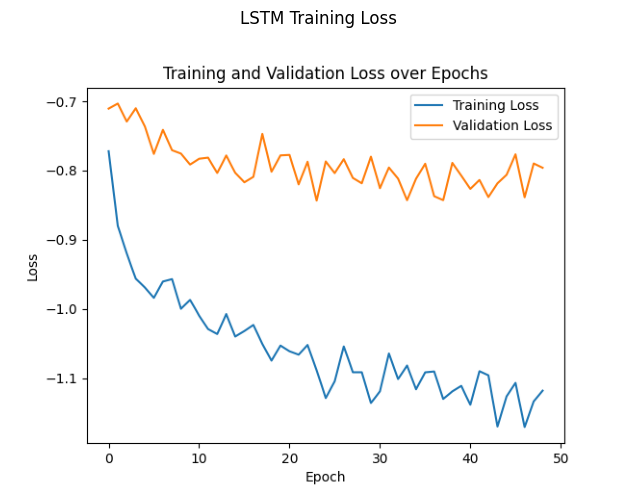

In [8]:
# Load LSTM results
LSTM_EXPERIMENT = "exp_lstm_split60_lstm_cpnone_len20_notime_val_v1"
lstm_results_dir = f"results/{LSTM_EXPERIMENT}/{TEST_START}-{TEST_END}"

lstm_csv = os.path.join(lstm_results_dir, "captured_returns_sw.csv")
if os.path.exists(lstm_csv):
    lstm_df = load_captured_returns(lstm_csv)
    lstm_returns = calc_daily_returns(lstm_df)
    
    # Raw metrics
    print("\n" + "="*60)
    print("LSTM Results (Raw)")
    print("="*60)
    metrics_raw = calc_metrics(lstm_returns, "LSTM")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['LSTM'] = lstm_returns
    
    # Vol-normalized metrics
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(lstm_returns, "LSTM", VOL_TARGET)
    display_metrics(metrics_norm)
    
    # Yearly Sharpes
    print("\nYearly Sharpe Ratios:")
    yearly_sharpes = calc_yearly_sharpes(lstm_returns)
    for year, sharpe in yearly_sharpes.items():
        print(f"  {year}: {sharpe:.4f}")
    
    # Loss curve
    print("\n")
    plot_loss_curve(lstm_results_dir, "LSTM Training Loss")
else:
    print(f"Results not found at: {lstm_csv}")

In [12]:
gcn_df = pd.read_csv("results/exp_lstm_gcn_split80_lstm-gcn_cpnone_len20_notime_val_v1/2017-2023/captured_returns_sw.csv")
gcn_df['time'] = pd.to_datetime(gcn_df['time'])

for year in range(2017, 2023):
    yr = gcn_df[gcn_df['time'].dt.year == year]
    if len(yr) > 0:
        mean_pos = yr['position'].mean()
        pos_ret_corr = yr['position'].corr(yr['returns'])
        print(f"{year}: mean_pos={mean_pos:.3f}, pos-ret corr={pos_ret_corr:.4f}")

2017: mean_pos=-0.913, pos-ret corr=0.0015
2018: mean_pos=-0.799, pos-ret corr=-0.0286
2019: mean_pos=-0.772, pos-ret corr=-0.0010
2020: mean_pos=-0.747, pos-ret corr=0.0261
2021: mean_pos=-0.805, pos-ret corr=0.0438
2022: mean_pos=-0.710, pos-ret corr=0.0160


---
## 5. Classical Strategies (Baselines)

Run Long Only, Short Only, and TSMOM strategies using the LSTM-GCN results as reference.

In [10]:
from gml.backtest import run_classical_methods
from settings.default import STRADDLE

print("="*60)
print("Running Classical Strategies (Baselines)")
print("="*60)

# Reference experiment (must have been run first)
REFERENCE_EXPERIMENT = LSTM_EXPERIMENT

# Features file
if STRADDLE:
    features_file_path = os.path.join("data", "straddle_features", "features.csv")
else:
    features_file_path = os.path.join("data", "equity_features", "features.csv")

# Intervals
INTERVALS = [(TRAIN_START, TEST_START, TEST_END)]

run_classical_methods(features_file_path, INTERVALS, REFERENCE_EXPERIMENT)

Running Classical Strategies (Baselines)
Processing train interval: (2011, 2017, 2023)
Saved raw captured returns to: results/tsmom_0/2017-2023/captured_returns_raw.csv
[Scaling Debug] Raw annual vol: 0.039132, scaling factor: 3.8332, new annual vol: 0.150000
Saved scaled captured returns to: results/tsmom_0/2017-2023/captured_returns_scaled.csv
Saved raw captured returns to: results/tsmom_0.5/2017-2023/captured_returns_raw.csv
[Scaling Debug] Raw annual vol: 0.035825, scaling factor: 4.1870, new annual vol: 0.150000
Saved scaled captured returns to: results/tsmom_0.5/2017-2023/captured_returns_scaled.csv
Saved raw captured returns to: results/tsmom_1/2017-2023/captured_returns_raw.csv
[Scaling Debug] Raw annual vol: 0.044049, scaling factor: 3.4053, new annual vol: 0.150000
Saved scaled captured returns to: results/tsmom_1/2017-2023/captured_returns_scaled.csv
Saved raw captured returns to: results/long_only/2017-2023/captured_returns_raw.csv
[Scaling Debug] Raw annual vol: 0.071122, 

,annual_return,annual_volatility,sharpe_ratio,downside_risk,sortino_ratio,max_drawdown,calmar_ratio,perc_pos_return,profit_loss_ratio,experiment,train_interval,scaling
0,0.011670,0.039132,0.316094,0.030099,0.410954,0.116904,0.099828,0.564286,0.818888,tsmom_0,"(2011, 2017, 2023)",raw
1,0.036754,0.150000,0.316094,0.115376,0.410954,0.387591,0.094826,0.564286,0.818888,tsmom_0,"(2011, 2017, 2023)",15% annualized
2,0.006540,0.035825,0.199890,0.027465,0.260730,0.109880,0.059521,0.562143,0.809182,tsmom_0.5,"(2011, 2017, 2023)",raw
3,0.018849,0.150000,0.199890,0.114998,0.260730,0.394873,0.047735,0.562143,0.809182,tsmom_0.5,"(2011, 2017, 2023)",15% annualized
4,0.000983,0.044049,0.044328,0.032679,0.059752,0.115098,0.008540,0.547143,0.834706,tsmom_1,"(2011, 2017, 2023)",raw
5,-0.004611,0.150000,0.044328,0.111280,0.059752,0.350700,-0.013148,0.547143,0.834706,tsmom_1,"(2011, 2017, 2023)",15% annualized
6,-0.071676,0.071122,-1.010124,0.047136,-1.524153,0.361821,-0.198099,0.398571,1.253465,long_only,"(2011, 2017, 2023)",raw
7,-0.150205,0.150000,-1.010124,0.099412,-1.524153,0.623716,-0.240822,0.398571,1.253465,long_only,"(2011, 2017, 2023)",15% annualized
8,0.071757,0.071122,1.010124,0.053418,1.344916,0.102307,0.701388,0.601429,0.797789,short_only,"(2011, 2017, 2023)",raw
9,0.150478,0.150000,1.010124,0.112660,1.344916,0.206056,0.730276,0.601429,0.797789,short_only,"(2011, 2017, 2023)",15% annualized


In [11]:
# Load and display Long Only results
print("\n" + "="*60)
print("Long Only Results")
print("="*60)

long_only_csv = f"results/long_only/{TEST_START}-{TEST_END}/captured_returns_sw.csv"
if os.path.exists(long_only_csv):
    long_only_df = load_captured_returns(long_only_csv)
    long_only_returns = calc_daily_returns(long_only_df)
    
    metrics_raw = calc_metrics(long_only_returns, "Long Only")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['Long Only'] = long_only_returns
    
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(long_only_returns, "Long Only", VOL_TARGET)
    display_metrics(metrics_norm)
else:
    print(f"Results not found at: {long_only_csv}")


Long Only Results
Results not found at: results/long_only/2017-2023/captured_returns_sw.csv


In [ ]:
# Load and display Short Only results
print("\n" + "="*60)
print("Short Only Results")
print("="*60)

short_only_csv = f"results/short_only/{TEST_START}-{TEST_END}/captured_returns_sw.csv"
if os.path.exists(short_only_csv):
    short_only_df = load_captured_returns(short_only_csv)
    short_only_returns = calc_daily_returns(short_only_df)
    
    metrics_raw = calc_metrics(short_only_returns, "Short Only")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['Short Only'] = short_only_returns
    
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(short_only_returns, "Short Only", VOL_TARGET)
    display_metrics(metrics_norm)
else:
    print(f"Results not found at: {short_only_csv}")

In [ ]:
# Load and display TSMOM results (momentum = 0, pure trend following)
print("\n" + "="*60)
print("TSMOM Results (Momentum = 0)")
print("="*60)

tsmom_csv = f"results/tsmom_0/{TEST_START}-{TEST_END}/captured_returns_sw.csv"
if os.path.exists(tsmom_csv):
    tsmom_df = load_captured_returns(tsmom_csv)
    tsmom_returns = calc_daily_returns(tsmom_df)
    
    metrics_raw = calc_metrics(tsmom_returns, "TSMOM (w=0)")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['TSMOM'] = tsmom_returns
    
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(tsmom_returns, "TSMOM", VOL_TARGET)
    display_metrics(metrics_norm)
else:
    # Try alternative path
    tsmom_csv_alt = f"results/tsmom_0/{TEST_START}-{TEST_END}/captured_returns_raw.csv"
    if os.path.exists(tsmom_csv_alt):
        tsmom_df = pd.read_csv(tsmom_csv_alt)
        tsmom_df['time'] = pd.to_datetime(tsmom_df['time'])
        tsmom_returns = calc_daily_returns(tsmom_df)
        
        metrics_raw = calc_metrics(tsmom_returns, "TSMOM (w=0)")
        display_metrics(metrics_raw)
        all_metrics.append(metrics_raw)
        all_daily_returns['TSMOM'] = tsmom_returns
    else:
        print(f"Results not found at: {tsmom_csv}")

---
## 6. Final Comparison

In [12]:
print("="*60)
print("FINAL COMPARISON - All Strategies")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Strategy')

# Format for display
display_df = comparison_df.copy()
for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}")

print("\nRaw Metrics:")
display(display_df)

FINAL COMPARISON - All Strategies

Raw Metrics:


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM,2.29%,2.07%,1.103,1.596,3.14%,0.727,59.07%,0.889


In [13]:
# Vol-normalized comparison
print(f"\nVolatility-Normalized Metrics (Target: {VOL_TARGET:.0%}):")

vol_norm_metrics = []
for name, returns in all_daily_returns.items():
    metrics, _ = calc_metrics_vol_normalized(returns, name, VOL_TARGET)
    metrics['Strategy'] = name  # Override the "(Vol-Norm)" suffix
    vol_norm_metrics.append(metrics)

vol_norm_df = pd.DataFrame(vol_norm_metrics)
vol_norm_df = vol_norm_df.set_index('Strategy')

# Format
display_vol_df = vol_norm_df.copy()
for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
    if col in display_vol_df.columns:
        display_vol_df[col] = display_vol_df[col].apply(lambda x: f"{x:.2%}")
for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
    if col in display_vol_df.columns:
        display_vol_df[col] = display_vol_df[col].apply(lambda x: f"{x:.3f}")

display(display_vol_df)


Volatility-Normalized Metrics (Target: 15%):


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM,16.67%,15.00%,1.103,1.596,21.54%,0.774,59.07%,0.889


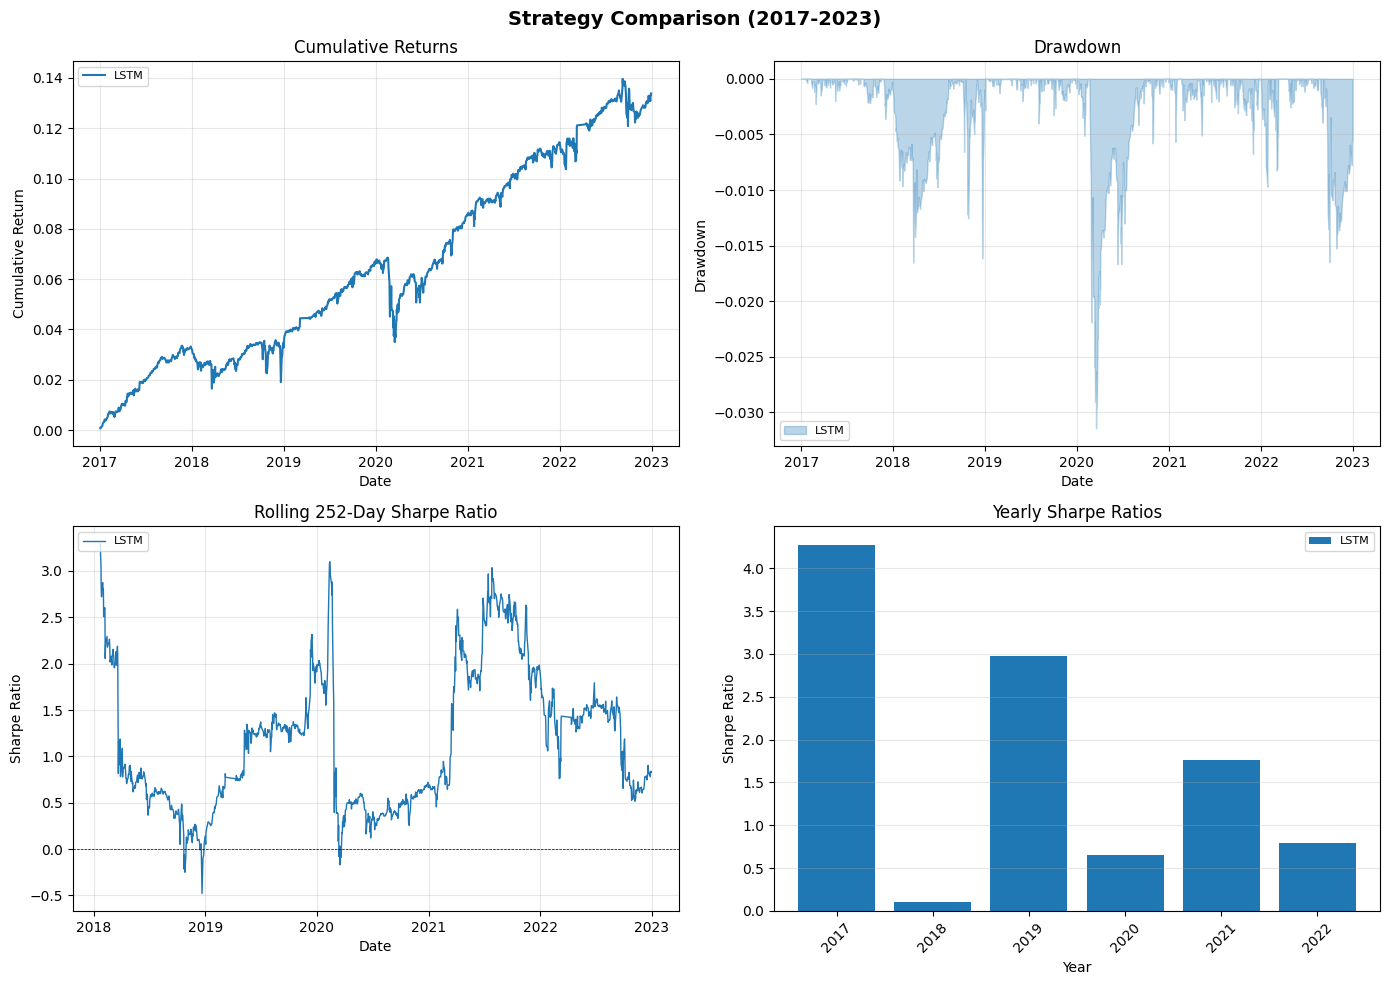

In [14]:
# Plot all strategies
if all_daily_returns:
    plot_results(all_daily_returns, f"Strategy Comparison ({TEST_START}-{TEST_END})")

In [15]:
# Yearly Sharpe comparison table
print("\nYearly Sharpe Ratios:")
yearly_sharpes_all = {}
for name, returns in all_daily_returns.items():
    yearly_sharpes_all[name] = calc_yearly_sharpes(returns)

yearly_df = pd.DataFrame(yearly_sharpes_all)
yearly_df = yearly_df.round(4)
yearly_df.loc['Average'] = yearly_df.mean()
display(yearly_df)


Yearly Sharpe Ratios:


,LSTM
2017,4.274900
2018,0.103100
2019,2.980400
2020,0.649300
2021,1.761300
2022,0.792700
Average,1.760283


In [16]:
# Save comparison to CSV
comparison_df.to_csv('results/strategy_comparison_metrics.csv')
vol_norm_df.to_csv('results/strategy_comparison_metrics_vol_normalized.csv')
yearly_df.to_csv('results/strategy_yearly_sharpes.csv')

print("\nResults saved to:")
print("  - results/strategy_comparison_metrics.csv")
print("  - results/strategy_comparison_metrics_vol_normalized.csv")
print("  - results/strategy_yearly_sharpes.csv")
print("  - results/strategy_comparison.png")


Results saved to:
  - results/strategy_comparison_metrics.csv
  - results/strategy_comparison_metrics_vol_normalized.csv
  - results/strategy_yearly_sharpes.csv
  - results/strategy_comparison.png


---
## 7. Summary

In [17]:
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nTraining Period: {TRAIN_START} - {TEST_START}")
print(f"Test Period:     {TEST_START} - {TEST_END}")
print(f"\nStrategies Evaluated: {len(all_daily_returns)}")
for name in all_daily_returns.keys():
    print(f"  - {name}")

if all_metrics:
    best_sharpe = max(all_metrics, key=lambda x: x['Sharpe'])
    print(f"\nBest Sharpe Ratio: {best_sharpe['Strategy']} ({best_sharpe['Sharpe']:.3f})")
    
    best_return = max(all_metrics, key=lambda x: x['E[Ret.]'])
    print(f"Best Annual Return: {best_return['Strategy']} ({best_return['E[Ret.]']:.2%})")
    
    best_sortino = max(all_metrics, key=lambda x: x['Sortino'])
    print(f"Best Sortino Ratio: {best_sortino['Strategy']} ({best_sortino['Sortino']:.3f})")

EXPERIMENT SUMMARY

Training Period: 2011 - 2017
Test Period:     2017 - 2023

Strategies Evaluated: 1
  - LSTM

Best Sharpe Ratio: LSTM (1.103)
Best Annual Return: LSTM (2.29%)
Best Sortino Ratio: LSTM (1.596)


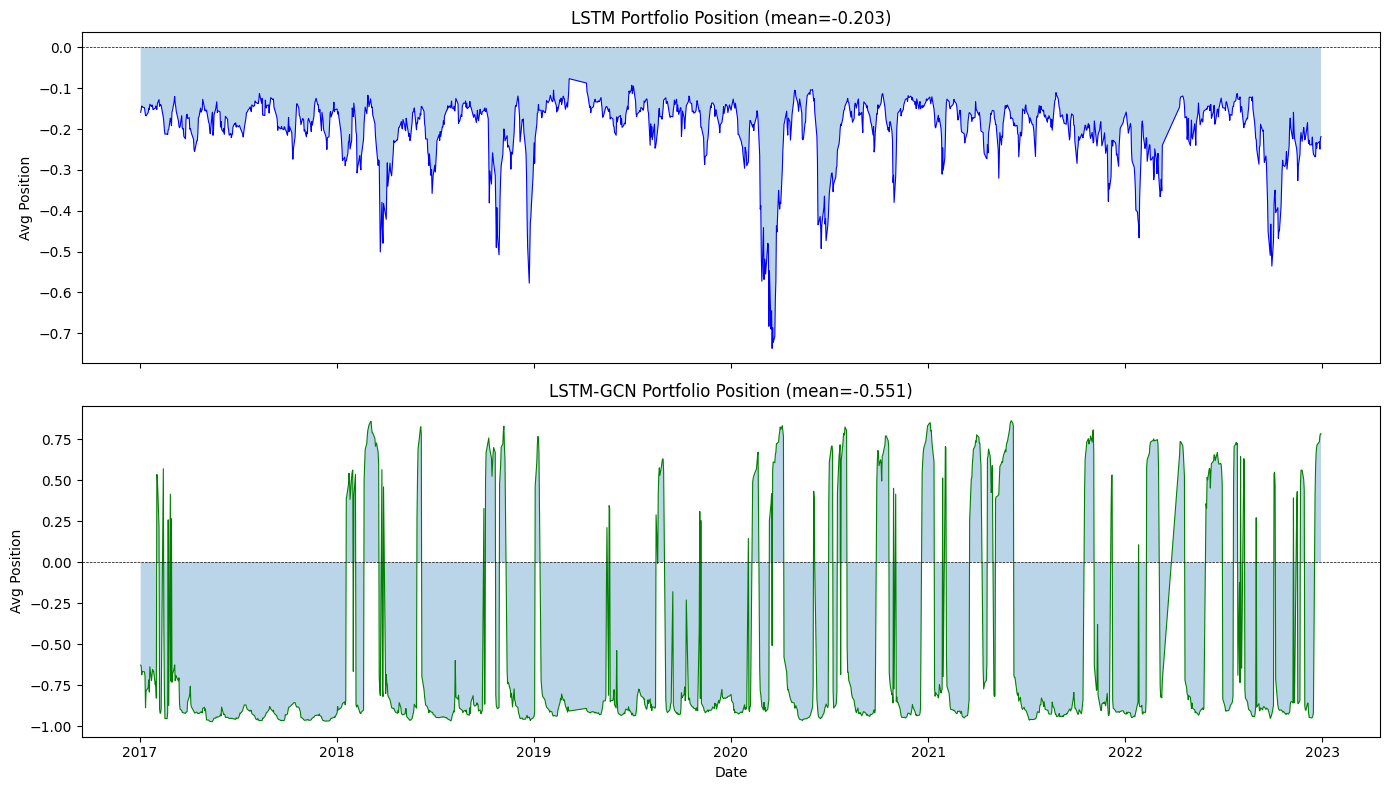

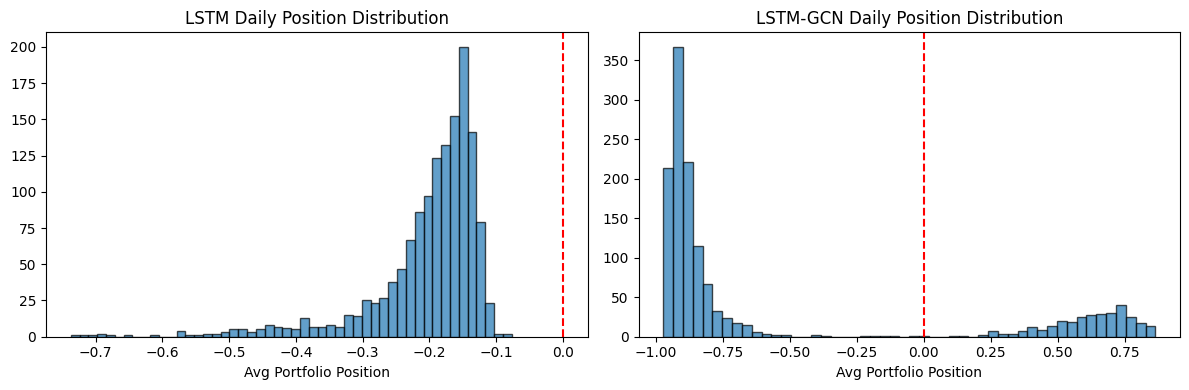


Position Statistics:
LSTM:     min=-0.737, max=-0.077, std=0.086
LSTM-GCN: min=-0.974, max=0.865, std=0.630


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Load results
lstm_df = pd.read_csv("results/exp_lstm_split60_lstm_cpnone_len20_notime_val_v1/2017-2023/captured_returns_sw.csv")
gcn_df = pd.read_csv("results/exp_lstm_gcn_split80_lstm-gcn_cpnone_len20_notime_val_v1/2017-2023/captured_returns_sw.csv")

lstm_df['time'] = pd.to_datetime(lstm_df['time'])
gcn_df['time'] = pd.to_datetime(gcn_df['time'])

# Calculate daily portfolio position (average across all tickers)
lstm_portfolio_pos = lstm_df.groupby('time')['position'].mean()
gcn_portfolio_pos = gcn_df.groupby('time')['position'].mean()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# LSTM
axes[0].plot(lstm_portfolio_pos.index, lstm_portfolio_pos.values, linewidth=0.8, color='blue')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[0].set_ylabel('Avg Position')
axes[0].set_title(f'LSTM Portfolio Position (mean={lstm_portfolio_pos.mean():.3f})')
axes[0].fill_between(lstm_portfolio_pos.index, 0, lstm_portfolio_pos.values, alpha=0.3)

# LSTM-GCN
axes[1].plot(gcn_portfolio_pos.index, gcn_portfolio_pos.values, linewidth=0.8, color='green')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_ylabel('Avg Position')
axes[1].set_title(f'LSTM-GCN Portfolio Position (mean={gcn_portfolio_pos.mean():.3f})')
axes[1].fill_between(gcn_portfolio_pos.index, 0, gcn_portfolio_pos.values, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Also show position distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lstm_portfolio_pos.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('LSTM Daily Position Distribution')
axes[0].set_xlabel('Avg Portfolio Position')

axes[1].hist(gcn_portfolio_pos.values, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('LSTM-GCN Daily Position Distribution')
axes[1].set_xlabel('Avg Portfolio Position')

plt.tight_layout()
plt.show()

# Print stats
print("\nPosition Statistics:")
print(f"LSTM:     min={lstm_portfolio_pos.min():.3f}, max={lstm_portfolio_pos.max():.3f}, std={lstm_portfolio_pos.std():.3f}")
print(f"LSTM-GCN: min={gcn_portfolio_pos.min():.3f}, max={gcn_portfolio_pos.max():.3f}, std={gcn_portfolio_pos.std():.3f}")